# Linear Regression

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ujjwal091/ai-ml-course/blob/main/modules/01-supervised-learning/01-linear-regression/notes.ipynb)

*The first concrete algorithm — fitting a straight line to data, and the machinery (cost function, gradient
descent, R²) that makes "fitting" a precise, repeatable process instead of a guess.*


## 1. The idea, and the running example

- Linear regression fits a straight line (one feature) or a hyperplane (two or more features) between a target and
  its features.
- Guessing a house's price yourself, you'd weigh location, size, age — those are the *features*; the price is the
  *target*.

**The case study we'll use throughout:** a Japanese automaker entering the US market wants to know what actually
drives car prices there.

- *Which* variables matter for predicting a car's price?
- *How well* do those variables explain the price?

**Dataset:** real Cars24 listings, already cleaned and normalized.

- **Input features (X):** `km_driven`, `mileage`, `engine`, `max_power`, `age`, `make`, `model`, plus categorical
  flags like `Individual`, `Trustmark Dealer`, `Diesel`, `Electric`.
- **Target (y):** `selling_price`

**Goal:** build a model that predicts a car's selling price from its features.


### 1.1 Load the data

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

This is the exact loading step from class — pulls the real dataset via `gdown` from Google Drive.

In [ ]:
!gdown 1qXoDeYVC4vhd7xTNwohxh9dMCjjtoHoJ -O ./data/cars24-car-price-cleaned-new.csv
df = pd.read_csv('data/cars24-car-price-cleaned-new.csv')  ## Loading the dataset
df.head()  ## Displaying the first 5 rows of the dataset for quick overview

### 1.2 Data notation

Before touching any code, it's worth pinning down the notation class actually uses for this — it shows up in
every formula from here on.

- We have $n$ historical cars — this is the *training data* we already know the price of.
- Each car has $d$ features: $f_1, f_2, f_3, \ldots, f_d$ (`max_power`, `mileage`, `age`, ...).
- $x_i$ — the full feature vector for the $i$-th car (all $d$ features, one row of the table).
- $y_i$ — the actual price of the $i$-th car (what we're trying to predict).

| | $f_1$ | $f_2$ | $\cdots$ | $f_d$ | $y$ |
|---|---|---|---|---|---|
| car 1 | | | | | $y_1$ |
| car 2 | | | | | $y_2$ |
| $\vdots$ | | $x_i$ (this whole row) | | | $\vdots$ |
| car $n$ | | | | | $y_n$ |

So: $x_i \to$ everything we know about car $i$. $y_i \to$ the one number we're trying to learn to predict from it.


### 1.3 The model as a black box

Once we've used the historical data $(x_i, y_i)$ pairs to build a model, using it is simple: hand it a new,
*unseen* car's features and it hands back a predicted price.


```{mermaid}
graph LR
    A["xq<br/>unseen datapoint"] --> B["Model"] --> C["Predicted price<br/>ŷ"]

    style A fill:#BFDBFE,stroke:#374151,stroke-width:2px,color:#111827
    style B fill:#FDE68A,stroke:#374151,stroke-width:2px,color:#111827
    style C fill:#A7F3D0,stroke:#374151,stroke-width:2px,color:#111827
```

A model is only useful if its prediction $\hat{y}$ (predicted) lands close to the real $y$ (actual) — that's
the entire game from here on: find a model where $\hat{y} \approx y$ as often and as closely as possible.


### 1.4 A tiny worked example, by hand — no code yet

Before the real Cars24 data, it's worth seeing the whole idea work on numbers small enough to do in your head.
Suppose this is all the historical data we have:

| $x_1$ | $x_2$ | $y$ |
|---|---|---|
| 1 | 2 | 4 |
| 2 | 2 | 6 |
| 2 | 3 | 7 |
| 3 | 4 | 10 |

**Can you spot the pattern relating $x_1$, $x_2$ to $y$?**

Try a few combinations before reading on — add them, double one and add the other, anything.


**Quick check**

> What's the rule that turns $(x_1, x_2)$ into $y$ for all four rows above?
>
> $y = 2x_1 + x_2$. Check it: $2(1)+2=4$ ✓, $2(2)+2=6$ ✓, $2(2)+3=7$ ✓, $2(3)+4=10$ ✓.


Now here's the real test — two *new* rows we held back:

| $x_1$ | $x_2$ | $y$ (actual) | $\hat{y}$ (from $y=2x_1+x_2$) |
|---|---|---|---|
| 4 | 4 | 12 | $2(4)+4=12$ ✓ |
| 5 | 4 | 14 | $2(5)+4=14$ ✓ |

Both match exactly — the pattern we found on the first 4 rows generalizes perfectly to rows the "model" never saw
while we were figuring out the rule. That's the entire point of a train/test split, just done by hand: **learn the
pattern on some rows, verify it holds on rows you deliberately held back.**

**Your turn:** using $y = 2x_1 + x_2$, what should $y$ be for $x_1=5, x_2=6$?


**Quick check**

> $x_1=5, x_2=6$ → what's $y$?
>
> $y = 2(5) + 6 = 16$.


## 2. Split the data into training and testing sets

Test size is usually 20% of the data. For a small dataset it's common to bump that to 30%, since a 20% slice might
be too little to evaluate on reliably. `random_state` fixes the random seed, so the split is reproducible — run it
again and you get exactly the same train/test division.


In [ ]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=40)

## 3. The equation of the line

Linear regression tries to fit a straight line through the data. For one feature:

$$
y = mx + c
$$

For multiple features, that becomes a weighted sum:

$$
y = m_1 x_1 + m_2 x_2 + m_3 x_3 + \cdots + c
$$

where $m_1, m_2, m_3, \ldots$ are the coefficients (one per feature) and $c$ is the intercept. "Fitting" the model
means finding the specific values of every $m_i$ and $c$ that make this line match the data as closely as
possible.


**Try it by hand first:** imagine one feature, and two candidate lines for the same 3 points — `(1, 3)`,
`(2, 5)`, `(3, 6)`.

- Line A: $y = 2x + 1$ → predicts 3, 5, 7 for x = 1, 2, 3. Errors: 0, 0, 1.
- Line B: $y = x + 3$ → predicts 4, 5, 6 for x = 1, 2, 3. Errors: 1, 0, 0.

Both lines get 2 out of 3 points exactly right — so which is actually "better" overall? You need a single number
that scores an entire line at once, not just point-by-point right/wrong. That's exactly what the error function
below is for.


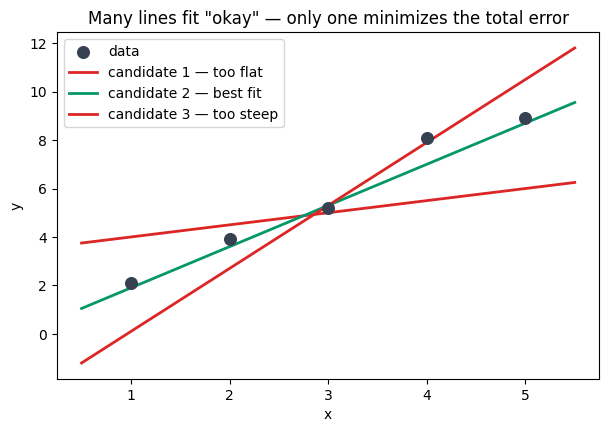

In [4]:
import numpy as np
import matplotlib.pyplot as plt

pts_x = np.array([1, 2, 3, 4, 5])
pts_y = np.array([2.1, 3.9, 5.2, 8.1, 8.9])

xs = np.linspace(0.5, 5.5, 50)
lines = [
    (0.5, 3.5, "#DC2626", "candidate 1 — too flat"),
    (1.7, 0.2, "#059669", "candidate 2 — best fit"),
    (2.6, -2.5, "#DC2626", "candidate 3 — too steep"),
]

plt.figure(figsize=(7, 4.5))
plt.scatter(pts_x, pts_y, color="#374151", zorder=5, s=70, label="data")
for m, c, color, label in lines:
    plt.plot(xs, m * xs + c, color=color, lw=2, label=label)
plt.title("Many lines fit \"okay\" — only one minimizes the total error")
plt.xlabel("x"); plt.ylabel("y")
plt.legend()
plt.show()

## 4. Prediction, error, and gradient descent

The loop: start with random $m$, $c$ → predict $y_{predicted} = mx + c$ → measure error → nudge $m$, $c$ to reduce
it → repeat.

**The error function — Mean Squared Error (MSE):**

$$
Error = \frac{1}{n} \sum (y - y_{predicted})^2
$$

- Same shape as $x^2$ — **convex**, one single global minimum. Wherever gradient descent starts, it always rolls
  down to that same minimum.


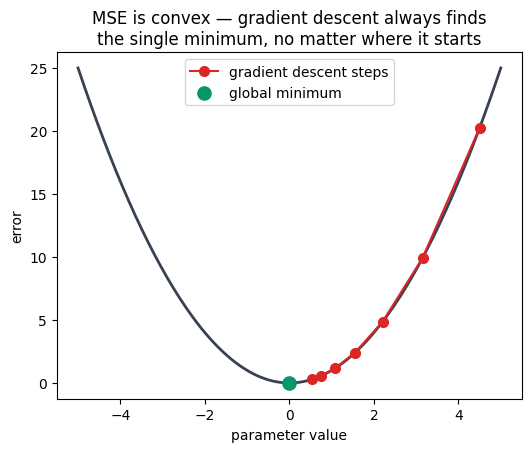

In [5]:
import numpy as np
import matplotlib.pyplot as plt

xs = np.linspace(-5, 5, 200)
ys = xs**2

# a few steps of gradient descent on f(x) = x^2, starting at x=4.5
path_x = [4.5]
lr = 0.15
for _ in range(6):
    grad = 2 * path_x[-1]
    path_x.append(path_x[-1] - lr * grad)
path_y = [x**2 for x in path_x]

plt.figure(figsize=(6, 4.5))
plt.plot(xs, ys, color="#374151", lw=2)
plt.plot(path_x, path_y, "o-", color="#DC2626", markersize=7, lw=1.5, label="gradient descent steps")
plt.scatter([0], [0], color="#059669", zorder=5, s=90, label="global minimum")
plt.title("MSE is convex — gradient descent always finds\nthe single minimum, no matter where it starts")
plt.xlabel("parameter value"); plt.ylabel("error")
plt.legend()
plt.show()

**Minimizing with gradient descent** — the general update rule for any parameter:

$$
x = x - \text{step\_size} \cdot \frac{d(Error)}{dx}
$$

For $x^2$, that's $x = x - \text{step\_size} \cdot (2x)$ — step opposite the slope, walk downhill. That's exactly
what the plot above just did.

**Expanding the error function** with $y_{predicted} = mx + c$ substituted in:

$$
Error = \frac{1}{n} \sum (y - (mx + c))^2
$$

**Partial derivatives** — how much the error changes as you nudge $m$ or $c$:

$$
\frac{d(Error)}{dm} = -\frac{2}{n} \sum (y - (mx + c)) \cdot x
\qquad\qquad
\frac{d(Error)}{dc} = -\frac{2}{n} \sum (y - (mx + c))
$$

**Parameter update rules**, using those gradients:

$$
m = m - \text{learning\_rate} \cdot \frac{d(Error)}{dm}
\qquad\qquad
c = c - \text{learning\_rate} \cdot \frac{d(Error)}{dc}
$$

**The full loop, one more time:** random $m$, $c$ → predict → MSE → gradient descent update → repeat until error
stops improving.


**Quick check**

> Why does gradient descent *subtract* the gradient rather than add it?
>
> The gradient points in the direction the error *increases* fastest. To make the error smaller, you move the
> opposite way — hence the minus sign in every update rule above. If you added the gradient instead, you'd be
> deliberately climbing uphill, and the error would grow with every step instead of shrinking.


## 5. R-squared (coefficient of determination)

- Question R² answers: **is this fitted line actually good?**
- How: compare your model's error against the simplest possible baseline — always predicting the average `y`.

$$
R^2 = 1 - \frac{RSS}{TSS}
$$

- $TSS = \sum (y - \bar{y})^2$ — error of the "always predict the mean" baseline.
- $RSS = \sum (y - y_{predicted})^2$ — error of the model you're actually evaluating.


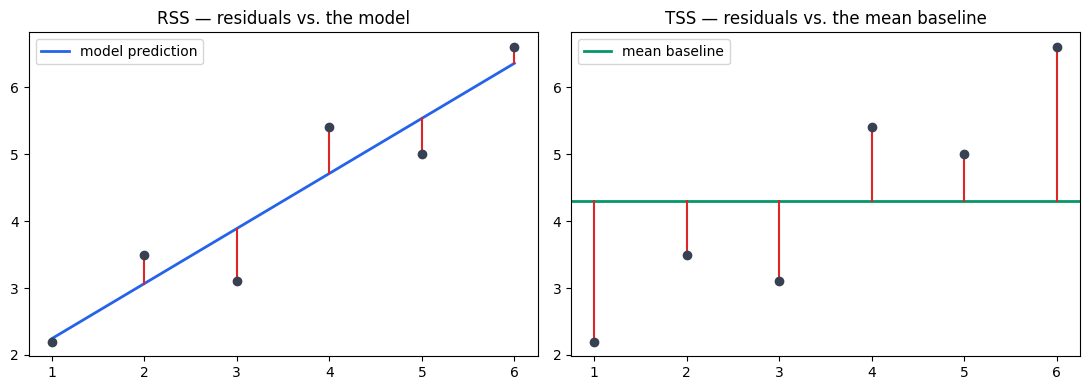

RSS (model)   : 1.63
TSS (baseline): 13.48
R-squared     : 0.879


In [6]:
toy_x = np.array([1, 2, 3, 4, 5, 6])
toy_y = np.array([2.2, 3.5, 3.1, 5.4, 5.0, 6.6])
m_fit, c_fit = np.polyfit(toy_x, toy_y, 1)
toy_pred = m_fit * toy_x + c_fit
toy_mean = np.mean(toy_y)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(toy_x, toy_y, color="#374151", zorder=5)
axes[0].plot(toy_x, toy_pred, color="#2563EB", lw=2, label="model prediction")
for x, y, p in zip(toy_x, toy_y, toy_pred):
    axes[0].plot([x, x], [y, p], color="#DC2626", lw=1.5)
axes[0].set_title("RSS — residuals vs. the model")
axes[0].legend()

axes[1].scatter(toy_x, toy_y, color="#374151", zorder=5)
axes[1].axhline(toy_mean, color="#059669", lw=2, label="mean baseline")
for x, y in zip(toy_x, toy_y):
    axes[1].plot([x, x], [y, toy_mean], color="#DC2626", lw=1.5)
axes[1].set_title("TSS — residuals vs. the mean baseline")
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"RSS (model)   : {np.sum((toy_y - toy_pred)**2):.2f}")
print(f"TSS (baseline): {np.sum((toy_y - toy_mean)**2):.2f}")
print(f"R-squared     : {1 - np.sum((toy_y - toy_pred)**2)/np.sum((toy_y - toy_mean)**2):.3f}")

**Reading the number:**
- $R^2 \approx 1$ → excellent fit — model's red lines (left) are much shorter than the baseline's (right).
- $R^2 \approx 0$ → no better than just guessing the average every time.
- $R^2 < 0$ → *worse* than the average-guessing baseline — the chosen $m$, $c$ are genuinely poor.
- Range: $(-\infty, 1]$.

**One line:** R² measures how much of the variance in the data your model explains, versus just predicting the
mean every time.


## 6. Building it from scratch — one feature first

Starting simple: predicting `selling_price` from `max_power` alone. This is the exact function built in class —
notice it scales `x` first (subtracts the mean, divides by the standard deviation), because gradient descent
converges far more reliably when features are on a similar scale.


In [7]:
def regression(x, y, m=1, c=0, learning_rate=0.001, threshold=0.001, max_iter=1000):
    # scaling the data.. will be described below
    x = (x - np.mean(x)) / np.std(x)

    n = len(x)
    prev_error = float('inf')

    for _ in range(max_iter):
        y_predicted = m * x + c
        # error = (1/n) * sum((y - y_predicted) ** 2)
        error = np.mean((y_predicted - y) ** 2)

        if abs(prev_error - error) < threshold:
            break

        # Calculate gradients
        dm = (-2 / n) * sum((y - y_predicted) * x)
        dc = (-2 / n) * sum(y - y_predicted)

        # Update parameters
        m = m - learning_rate * dm
        c = c - learning_rate * dc

        prev_error = error

    return m, c

In [ ]:
regression(x=df['max_power'], y=df['selling_price'])

## 7. Generalizing to multiple features

The single-feature version only handles one $m$. Real problems have several features at once — `max_power` and
`mileage` together, say — so the class notebook generalizes it: `m` becomes a weight *vector* `w` (one weight per
feature), and the math becomes matrix operations instead of a single multiply.


In [9]:
import numpy as np
from typing import Tuple, Optional


def regression(
        x: np.ndarray,  # (n_samples, n_features)
        y: np.ndarray,  # (n_samples,)
        w: Optional[np.ndarray] = None,  # (n_features,)
        b: float = 0.0,
        learning_rate: float = 0.01,
        threshold: float = 1e-6,
        max_iter: int = 1000
) -> Tuple[np.ndarray, float]:
    # Ensure numpy arrays
    x = np.asarray(x)
    x = (x - np.mean(x, axis=0)) / np.std(x, axis=0)

    y = np.asarray(y)

    n, n_features = x.shape

    # Initialize weights if not provided
    if w is None:
        w = np.zeros(n_features)

    prev_error = float('inf')

    for _ in range(max_iter):

        # Predictions
        y_predicted = np.dot(x, w) + b

        # Mean Squared Error
        error = np.mean((y_predicted - y) ** 2)

        # Convergence check
        if abs(prev_error - error) < threshold:
            break

        # Gradients
        dw = (2 / n) * np.dot(x.T, (y_predicted - y))
        db = (2 / n) * np.sum(y_predicted - y)

        # Update
        w -= learning_rate * dw
        b -= learning_rate * db

        prev_error = error

    return w, b

In [ ]:
x = df[['max_power', 'mileage']].values
y = df['selling_price'].values

regression(x, y)

## 8. Scoring the fit with R²

In [11]:
def calculate_r_squared(y_true, y_pred):
    mean = np.mean(y_true)
    rss = np.sum((y_true - y_pred) ** 2)
    tss = np.sum((y_true - mean) ** 2)

    return 1 - (rss / tss)

In [ ]:
# Train
w, b = regression(x, y)

# Manually scale x the same way
x_scaled = (x - np.mean(x, axis=0)) / np.std(x, axis=0)

# Predict
predicted_car_price = np.dot(x_scaled, w) + b

# R2
r_squared = calculate_r_squared(y, predicted_car_price)
print(f"R-squared: {r_squared:.4f}")

## 9. Same thing, using scikit-learn
Once you understand what's happening underneath, this is the version you'd actually reach for day to day.

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x, y)

print(model.coef_)
print(model.intercept_)

In [ ]:
predicted_car_price = model.predict(x)
r_squared = calculate_r_squared(y, predicted_car_price)
print(f"R-squared: {r_squared:.4f}")

## 10. Practice exercise (left unfinished on purpose)

This one was left as an in-class exercise — write a min-max normalization function that rescales an array so its
values land between `n_min` and `n_max`. The formula for min-max normalization is:

$$
x_{norm} = n_{min} + \frac{(x - x_{min})(n_{max} - n_{min})}{x_{max} - x_{min}}
$$

The starter code (with the bug still in it — `max` gets shadowed by the loop variable, and `norm_arr` is never
actually computed) is preserved exactly as it was left, so it's still there to attempt:


In [15]:
import numpy as np
def fnc(arr, n_min,n_max):
    '''
    input:
    arr-> the input numpy array to the function
    n_min -> an integer specifying the n_min value as mentioned in the problem statement
    n_max -> an integer specifying the n_max value as mentioned in the problem statement
    output:
    norm_arr -> the normalized numpy array
    '''
    # YOUR CODE GOES HERE

    diff = n_max-n_min
    max = max(arr)

    norm_arr = None


    # YOUR CODE ENDS HERE
    return norm_arr

## 11. Summary — revision cheat sheet

**The model:** $y = m_1x_1 + m_2x_2 + \cdots + c$ — a straight line (one feature) or a hyperplane (two or more
features) fit through the data.

**Fitting it — the loop:** start with random $m$, $c$ → predict → measure error with MSE → nudge $m$, $c$ downhill
via gradient descent → repeat until the error stops meaningfully improving.

**Core definitions:**
- *MSE (the error function)* — $\frac{1}{n}\sum(y - y_{predicted})^2$; convex, so it has a single global minimum
  and gradient descent always finds it.
- *Gradient descent* — repeatedly step each parameter opposite its gradient:
  $\theta = \theta - \text{learning\_rate} \cdot \frac{d(Error)}{d\theta}$.
- *R² (coefficient of determination)* — $1 - RSS/TSS$; how much better your model does than just predicting the
  mean every time. Range $(-\infty, 1]$; near 1 is a great fit, near 0 is no better than the mean, negative is
  worse than the mean.
- *Feature scaling* — subtract the mean, divide by the standard deviation, before fitting. Both from-scratch
  implementations above do this internally; it's what makes gradient descent converge reliably.

**Practical must-do:** always split into train/test before fitting, and never let the model see the test set
during training — that's the only way the R² (or any other metric) you compute afterward actually means anything.

**Next up:** more on evaluating and improving a regression model — polynomial regression, bias/variance,
regularization, and cross-validation.
